In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.plotting_fns import PlottingFns
from region import Region
from functions import Functions
pfns = PlottingFns()
fns = Functions()

In [3]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
from cartopy.feature import LAND
from gsw import conversions, density
from glob import glob


In [4]:
f140 = '../data/SOSE/Adelie_140E_*.nc'
f145 = '../data/SOSE/Adelie_145E_*.nc'
fseg = '../data/SOSE/Adelie_138E_150E/Adelie*.nc'

In [5]:
ds140 = xr.open_mfdataset(glob(f140))
ds145 = xr.open_mfdataset(glob(f145))

In [6]:
dsseg = xr.open_mfdataset(glob(fseg))

In [7]:
gyre_index = xr.open_dataarray('gyre_index.nc')
sla_ = SLA(deg=0.25).da


In [8]:
ds145

<xarray.Dataset> Size: 275MB
Dimensions:  (YC: 322, YG: 322, Z: 52, Zu: 52, Zl: 52, Zp1: 53, time: 803)
Coordinates: (12/23)
    XC       float64 8B 144.9
    XG       float64 8B 145.0
  * YC       (YC) float64 3kB -77.98 -77.95 -77.91 ... -60.18 -60.1 -60.02
  * YG       (YG) float64 3kB -78.0 -77.97 -77.93 -77.9 ... -60.23 -60.14 -60.06
  * Z        (Z) float64 416B -2.1 -6.7 -12.15 ... -5e+03 -5.4e+03 -5.8e+03
  * Zu       (Zu) int64 416B 0 1 2 3 4 5 6 7 8 9 ... 43 44 45 46 47 48 49 50 51
    ...       ...
    rAs      (YG) float64 3kB dask.array<chunksize=(322,), meta=np.ndarray>
    drC      (Zp1) float64 424B dask.array<chunksize=(53,), meta=np.ndarray>
    drF      (Z) float64 416B dask.array<chunksize=(52,), meta=np.ndarray>
    hFacC    (Z, YC) float64 134kB dask.array<chunksize=(52, 322), meta=np.ndarray>
    hFacW    (Z, YC) float64 134kB dask.array<chunksize=(52, 322), meta=np.ndarray>
    hFacS    (Z, YG) float64 134kB dask.array<chunksize=(52, 322), meta=np.ndarray>
Data variables:
    THETA    (time, Z, YC) float32 54MB dask.array<chunksize=(73, 52, 322), meta=np.ndarray>
    SALT     (time, Z, YC) float32 54MB dask.array<chunksize=(73, 52, 322), meta=np.ndarray>
    UVEL     (time, Z, YC) float32 54MB dask.array<chunksize=(73, 52, 322), meta=np.ndarray>
    VVEL     (time, Z, YG) float32 54MB dask.array<chunksize=(73, 52, 322), meta=np.ndarray>
    WVEL     (time, Zl, YC) float32 54MB dask.array<chunksize=(73, 52, 322), meta=np.ndarray>
    ETAN     (time, YC) float32 1MB dask.array<chunksize=(73, 322), meta=np.ndarray>
    SIarea   (time, YC) float32 1MB dask.array<chunksize=(73, 322), meta=np.ndarray>
    SIheff   (time, YC) float32 1MB dask.array<chunksize=(73, 322), meta=np.ndarray>
    PHIBOT   (time, YC) float32 1MB dask.array<chunksize=(73, 322), meta=np.ndarray>
    BLGMLD   (time, YC) float32 1MB dask.array<chunksize=(73, 322), meta=np.ndarray>

In [9]:
dsseg

<xarray.Dataset> Size: 918MB
Dimensions:  (XC: 72, XG: 73, YC: 15, YG: 14, Z: 52, Zu: 52, Zl: 52, Zp1: 53,
              time: 803)
Coordinates: (12/23)
  * XC       (XC) float64 576B 138.1 138.2 138.4 138.6 ... 149.6 149.8 149.9
  * XG       (XG) float64 584B 138.0 138.2 138.3 138.5 ... 149.7 149.8 150.0
  * YC       (YC) float64 120B -65.97 -65.91 -65.84 ... -65.15 -65.08 -65.01
  * YG       (YG) float64 112B -65.94 -65.87 -65.8 ... -65.18 -65.11 -65.04
  * Z        (Z) float64 416B -2.1 -6.7 -12.15 ... -5e+03 -5.4e+03 -5.8e+03
  * Zu       (Zu) int64 416B 0 1 2 3 4 5 6 7 8 9 ... 43 44 45 46 47 48 49 50 51
    ...       ...
    rAs      (YG, XC) float64 8kB dask.array<chunksize=(14, 72), meta=np.ndarray>
    drC      (Zp1) float64 424B dask.array<chunksize=(53,), meta=np.ndarray>
    drF      (Z) float64 416B dask.array<chunksize=(52,), meta=np.ndarray>
    hFacC    (Z, YC, XC) float64 449kB dask.array<chunksize=(52, 15, 72), meta=np.ndarray>
    hFacW    (Z, YC, XG) float64 456kB dask.array<chunksize=(52, 15, 73), meta=np.ndarray>
    hFacS    (Z, YG, XC) float64 419kB dask.array<chunksize=(52, 14, 72), meta=np.ndarray>
Data variables:
    ETAN     (time, YC, XC) float32 3MB dask.array<chunksize=(73, 15, 72), meta=np.ndarray>
    SIarea   (time, YC, XC) float32 3MB dask.array<chunksize=(73, 15, 72), meta=np.ndarray>
    SIheff   (time, YC, XC) float32 3MB dask.array<chunksize=(73, 15, 72), meta=np.ndarray>
    SIuice   (time, YC, XG) float32 4MB dask.array<chunksize=(73, 15, 73), meta=np.ndarray>
    SIvice   (time, YG, XC) float32 3MB dask.array<chunksize=(73, 14, 72), meta=np.ndarray>
    SIhsnow  (time, YC, XC) float32 3MB dask.array<chunksize=(73, 15, 72), meta=np.ndarray>
    BLGMLD   (time, YC, XC) float32 3MB dask.array<chunksize=(73, 15, 72), meta=np.ndarray>
    THETA    (time, Z, YC, XC) float32 180MB dask.array<chunksize=(73, 52, 15, 72), meta=np.ndarray>
    SALT     (time, Z, YC, XC) float32 180MB dask.array<chunksize=(73, 52, 15, 72), meta=np.ndarray>
    UVEL     (time, Z, YC, XG) float32 183MB dask.array<chunksize=(73, 52, 15, 73), meta=np.ndarray>
    VVEL     (time, Z, YG, XC) float32 168MB dask.array<chunksize=(73, 52, 14, 72), meta=np.ndarray>
    WVEL     (time, Zl, YC, XC) float32 180MB dask.array<chunksize=(73, 52, 15, 72), meta=np.ndarray>

In [10]:
extent_ac = [138,152,-68,-63]
extent_gyre = [145,150,-66.5,-65.5]
extent_ea=[60,160,-70,-60]

region_ac = Region('AC',extent_ac)
sla = region_ac.crop_da(sla_)

# filter dodgy sla signal
lonboo = sla.longitude < 147
latboo = sla.latitude > -66.6
sla = sla.where(lonboo | latboo,drop=True)

u,v = fns.get_geostrophic_currents(sla)
geos = xr.Dataset({'u10':u,'v10':v})

In [11]:
# chop and resample SOSE
ds = ds145.sel(YC = slice(-67.5,-65)).sel(YG = slice(-67.5,-65))
ds = ds.resample({'time':'MS'}).mean()
dsseg = dsseg.resample({'time':'MS'}).mean()

In [12]:
ds.load()

<xarray.Dataset> Size: 5MB
Dimensions:  (YC: 38, YG: 37, Z: 52, Zu: 52, Zl: 52, Zp1: 53, time: 132)
Coordinates: (12/22)
    XC       float64 8B 144.9
    XG       float64 8B 145.0
  * YC       (YC) float64 304B -67.49 -67.42 -67.36 ... -65.15 -65.08 -65.01
  * YG       (YG) float64 296B -67.46 -67.39 -67.33 ... -65.18 -65.11 -65.04
  * Z        (Z) float64 416B -2.1 -6.7 -12.15 ... -5e+03 -5.4e+03 -5.8e+03
  * Zu       (Zu) int64 416B 0 1 2 3 4 5 6 7 8 9 ... 43 44 45 46 47 48 49 50 51
    ...       ...
    drC      (Zp1) float64 424B 2.1 4.6 5.45 6.4 7.7 ... 400.0 400.0 400.0 200.0
    drF      (Z) float64 416B 4.2 5.0 5.9 6.9 8.5 ... 400.0 400.0 400.0 400.0
    hFacC    (Z, YC) float64 16kB 0.0 0.0 0.0 1.0 1.0 ... 0.0 0.0 0.0 0.0 0.0
    hFacW    (Z, YC) float64 16kB 0.0 0.0 0.0 0.0 1.0 ... 0.0 0.0 0.0 0.0 0.0
    hFacS    (Z, YG) float64 15kB 0.0 0.0 0.0 1.0 1.0 ... 0.0 0.0 0.0 0.0 0.0
  * time     (time) datetime64[ns] 1kB 2013-01-01 2013-02-01 ... 2023-12-01
Data variables:
    THETA    (time, Z, YC) float32 1MB 0.0 0.0 0.0 -1.765 ... 0.0 0.0 0.0 0.0
    SALT     (time, Z, YC) float32 1MB 0.0 0.0 0.0 33.82 ... 0.0 0.0 0.0 0.0
    UVEL     (time, Z, YC) float32 1MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    VVEL     (time, Z, YG) float32 1MB 0.0 0.0 0.0 0.008925 ... 0.0 0.0 0.0 0.0
    WVEL     (time, Zl, YC) float32 1MB 0.0 0.0 0.0 -6.027e-07 ... 0.0 0.0 0.0
    ETAN     (time, YC) float32 20kB 0.0 0.0 0.0 -3.783 ... -1.804 -1.788 -1.786
    SIarea   (time, YC) float32 20kB 0.0 0.0 0.0 0.8482 ... 0.6152 0.6117 0.62
    SIheff   (time, YC) float32 20kB 0.0 0.0 0.0 2.234 ... 0.3674 0.356 0.3571
    PHIBOT   (time, YC) float32 20kB -2.135 -2.142 -2.149 ... -8.247 3.142 3.131
    BLGMLD   (time, YC) float32 20kB 4.2 4.2 4.2 18.79 ... 46.52 46.66 41.94

In [13]:
# compute density etc
ds['pressure'] = conversions.p_from_z(ds.Z,ds.YC.mean())
ds['asal'] = conversions.SA_from_SP(ds.SALT,ds.pressure,145,ds.YC).where(-ds.Z < ds.Depth,drop=True)
ds['ctemp'] = conversions.CT_from_t(ds.asal,ds.THETA,ds.pressure).where(-ds.Z < ds.Depth,drop=True)
ds['rho'] = density.rho(ds.asal,ds.ctemp,ds.pressure)
ds['sigma0'] = density.sigma0(ds.asal,ds.ctemp)

In [14]:
# prepare other data
sa_sla = fns.seasonal_anomaly(sla.sel(time=slice(ds.time[0],sla.time[-1])))
sa_geos = fns.seasonal_anomaly(geos.sel(time=slice(ds.time[0],sla.time[-1])))
sa_gyre = fns.seasonal_anomaly(gyre_index.sel(time=slice(ds.time[0],ds.time[-1])))
sa_sose = fns.seasonal_anomaly(ds)

ssn_gyre = fns.season_split(sa_gyre)
ssn_sla = fns.season_split(sa_sla)
ssn_geos = fns.season_split(sa_geos)
ssn_sose = fns.season_split(sa_sose)

In [15]:
ds

<xarray.Dataset> Size: 14MB
Dimensions:   (YC: 38, YG: 37, Z: 52, Zu: 52, Zl: 52, Zp1: 53, time: 132)
Coordinates: (12/22)
  * YC        (YC) float64 304B -67.49 -67.42 -67.36 ... -65.15 -65.08 -65.01
  * YG        (YG) float64 296B -67.46 -67.39 -67.33 ... -65.18 -65.11 -65.04
  * Z         (Z) float64 416B -2.1 -6.7 -12.15 ... -5e+03 -5.4e+03 -5.8e+03
  * Zu        (Zu) int64 416B 0 1 2 3 4 5 6 7 8 9 ... 43 44 45 46 47 48 49 50 51
  * Zl        (Zl) float64 416B 0.0 -4.2 -9.2 ... -4.8e+03 -5.2e+03 -5.6e+03
  * Zp1       (Zp1) float64 424B 0.0 -4.2 -9.2 ... -5.2e+03 -5.6e+03 -6e+03
    ...        ...
    rAs       (YG) float64 296B 5.047e+07 5.074e+07 ... 6.082e+07 6.114e+07
    drC       (Zp1) float64 424B 2.1 4.6 5.45 6.4 ... 400.0 400.0 400.0 200.0
    drF       (Z) float64 416B 4.2 5.0 5.9 6.9 8.5 ... 400.0 400.0 400.0 400.0
    hFacC     (Z, YC) float64 16kB 0.0 0.0 0.0 1.0 1.0 ... 0.0 0.0 0.0 0.0 0.0
    hFacW     (Z, YC) float64 16kB 0.0 0.0 0.0 0.0 1.0 ... 0.0 0.0 0.0 0.0 0.0
    hFacS     (Z, YG) float64 15kB 0.0 0.0 0.0 1.0 1.0 ... 0.0 0.0 0.0 0.0 0.0
Data variables: (12/15)
    THETA     (time, Z, YC) float32 1MB 0.0 0.0 0.0 -1.765 ... 0.0 0.0 0.0 0.0
    SALT      (time, Z, YC) float32 1MB 0.0 0.0 0.0 33.82 ... 0.0 0.0 0.0 0.0
    UVEL      (time, Z, YC) float32 1MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    VVEL      (time, Z, YG) float32 1MB 0.0 0.0 0.0 0.008925 ... 0.0 0.0 0.0 0.0
    WVEL      (time, Zl, YC) float32 1MB 0.0 0.0 0.0 -6.027e-07 ... 0.0 0.0 0.0
    ETAN      (time, YC) float32 20kB 0.0 0.0 0.0 ... -1.804 -1.788 -1.786
    ...        ...
    BLGMLD    (time, YC) float32 20kB 4.2 4.2 4.2 18.79 ... 46.52 46.66 41.94
    pressure  (Z) float64 416B 2.121 6.767 12.27 ... 5.524e+03 5.939e+03
    asal      (time, Z, YC) float64 2MB nan nan nan 33.98 ... nan nan nan nan
    ctemp     (time, Z, YC) float64 2MB nan nan nan -1.761 ... nan nan nan nan
    rho       (time, Z, YC) float64 2MB nan nan nan 1.027e+03 ... nan nan nan
    sigma0    (time, Z, YC) float64 2MB nan nan nan 27.22 ... nan nan nan nan

In [16]:
rho_w = 1028.5
rho_ice = 910
rho_snow = 330

sload = (dsseg.SIheff * rho_ice) + (dsseg.SIhsnow * rho_snow)

sload = sload / rho_w

# correct SSH for loading
sea_level = (dsseg.ETAN + sload)


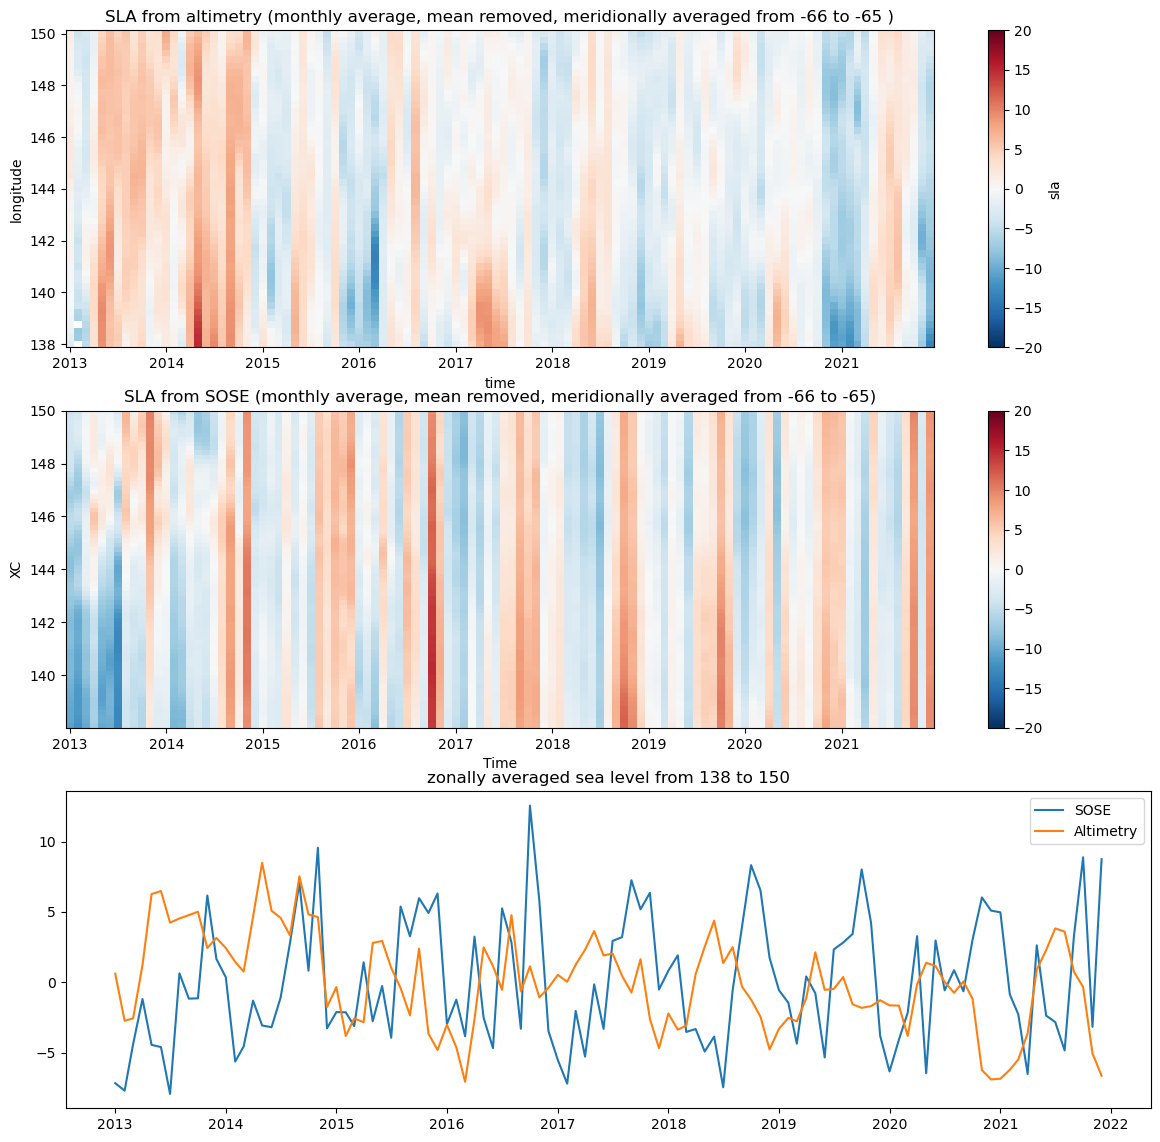

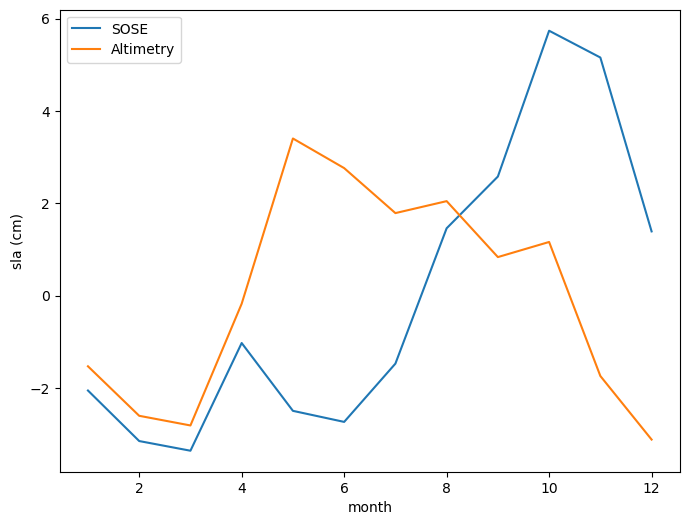

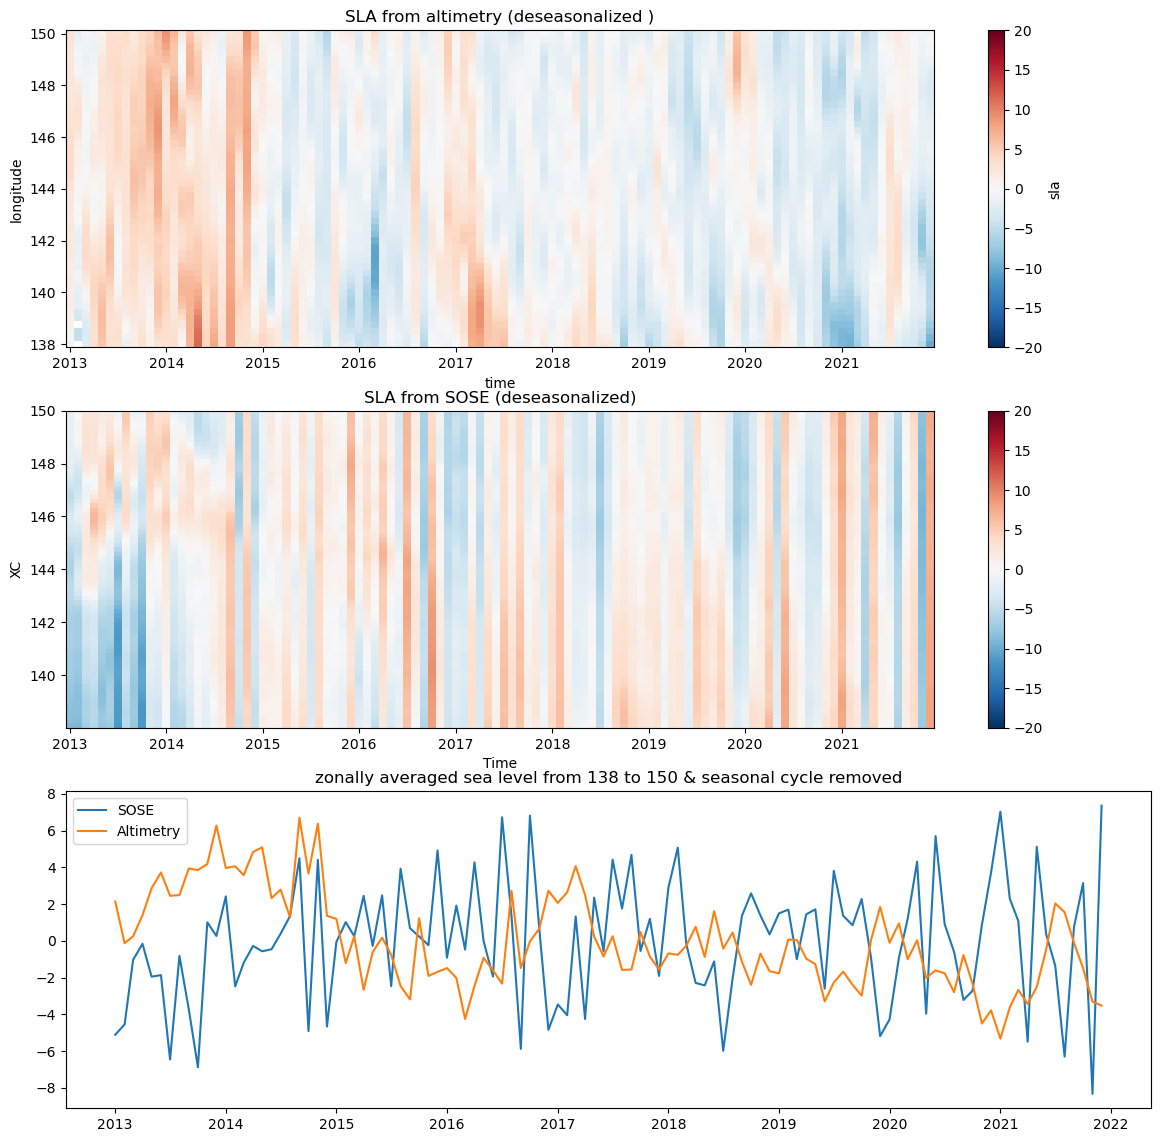

In [17]:
sla145 = sla.sel(latitude=slice(dsseg.YC[0],dsseg.YC[-1])).mean('latitude').sel(time=slice(ds.time[0],sla.time[-1])).sel(longitude=slice(138,150))
etaSOS = sea_level.mean('YC').sel(time=slice(ds.time[0],sla.time[-1]))

fig,axs = plt.subplots(3,1,figsize=(14,14))

slam = sla145 - sla145.mean('time')
etam = (etaSOS - etaSOS.mean('time')) * 100

ax=axs[0]
slam.plot(x='time',y='longitude',ax=ax,vmin=-20)
ax.set_title('SLA from altimetry (monthly average, mean removed, meridionally averaged from -66 to -65 )')
#ax.set_ylim([-66.5,-65])

ax=axs[1]
etam.plot(x='time',y='XC',ax=ax,vmin=-20)
ax.set_title('SLA from SOSE (monthly average, mean removed, meridionally averaged from -66 to -65)')
#ax.set_ylim([-66.5,-65])

ax=axs[2]
ax.plot(etam.time,etam.mean('XC'),label = 'SOSE')
ax.plot(slam.time,slam.mean('longitude'), label = 'Altimetry')
ax.set_title('zonally averaged sea level from 138 to 150')
ax.legend()

fig,ax = plt.subplots(figsize=(8,6))
soseclim=etam.mean('XC').groupby('time.month').mean()
alticlim=slam.mean('longitude').groupby('time.month').mean()

ax.plot(soseclim.month,soseclim,label='SOSE')
ax.plot(alticlim.month,alticlim,label='Altimetry')
ax.legend()
ax.set_xlabel('month')
ax.set_ylabel('sla (cm)')

fig,axs = plt.subplots(3,1,figsize=(14,14))

slama = slam.groupby('time.month') - alticlim
etama = etam.groupby('time.month') - soseclim


ax=axs[0]
slama.plot(x='time',y='longitude',ax=ax,vmin=-20)
ax.set_title('SLA from altimetry (deseasonalized )')
#ax.set_ylim([-66.5,-65])

ax=axs[1]
etama.plot(x='time',y='XC',ax=ax,vmin=-20)
ax.set_title('SLA from SOSE (deseasonalized)')
#ax.set_ylim([-66.5,-65])

ax=axs[2]
ax.plot(etama.time,etama.mean('XC'),label = 'SOSE')
ax.plot(slama.time,slama.mean('longitude'), label = 'Altimetry')
ax.set_title('zonally averaged sea level from 138 to 150 & seasonal cycle removed')
ax.legend()


(-1500.0, 0.0)

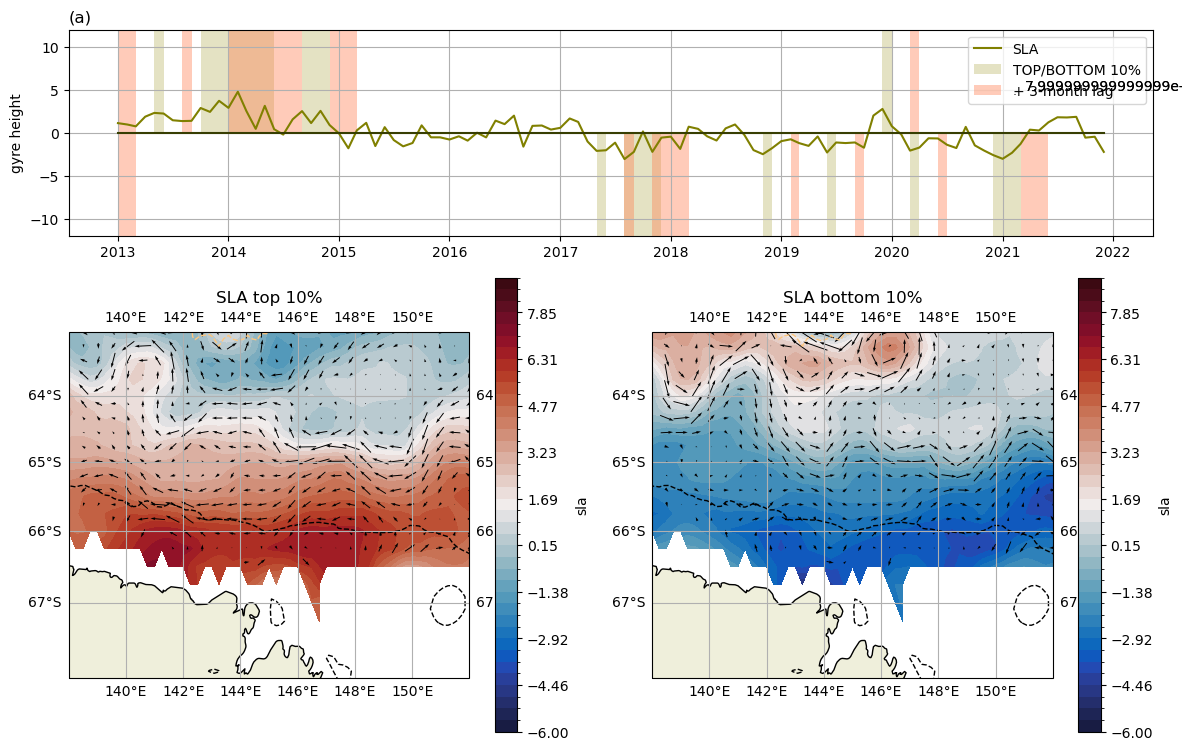

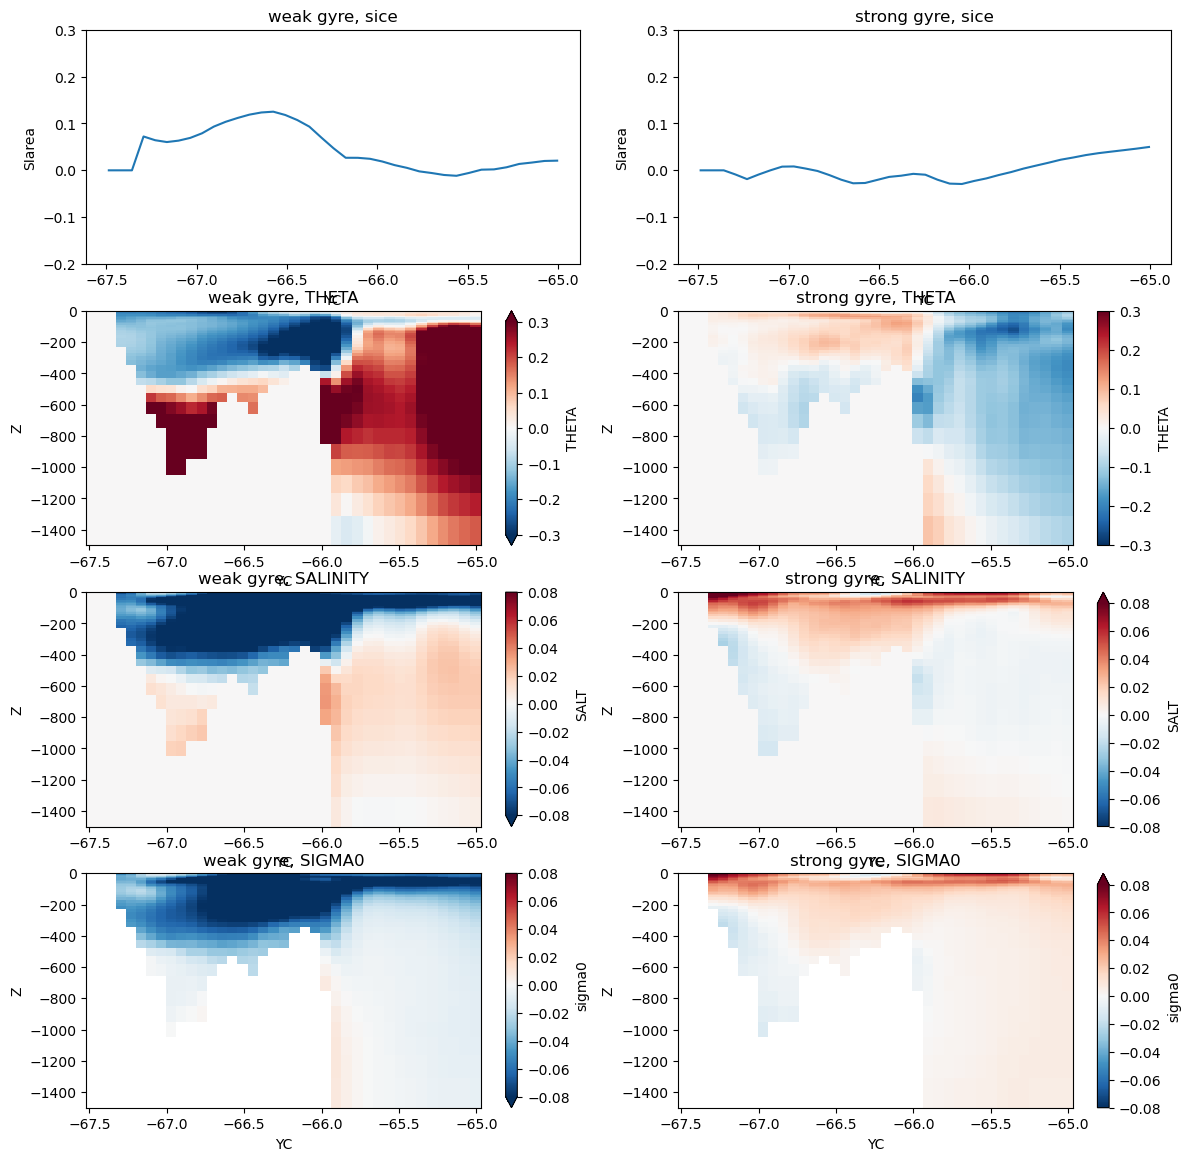

In [18]:
s = 'autumn'
lag=3
frac=0.1

topboo, botboo, top, bot = fns.get_topbot(sa_gyre,frac)#ssn_gyre[s],frac)
fns.run_for_idx(sa_gyre,frac,sa_sla,sa_geos,'SLA',extent_ac,lag=lag)#ssn_gyre[s],frac,ssn_sla[s],ssn_geos[s],'SLA',extent_ac,lag=lag)
fig,axs = plt.subplots(4,2,figsize=(14,14))

z = -1500
tops = top(sa_sose,lag)#ssn_sose[s],lag)
bots = bot(sa_sose,lag)#ssn_sose[s],lag)

ax = axs[0]
tops.SIarea.plot(ax=ax[0])
ax[0].set_title('weak gyre, sice')
ax[0].set_ylim([-0.2,0.3])

bots.SIarea.plot(ax=ax[1])
ax[1].set_title('strong gyre, sice')
ax[1].set_ylim([-0.2,0.3])

ax = axs[1]
tops.THETA.plot(ax=ax[0],vmin=-0.3)
ax[0].set_title('weak gyre, THETA')
ax[0].set_ylim([z,0])

bots.THETA.plot(ax=ax[1],vmin=-0.3)
ax[1].set_title('strong gyre, THETA')
ax[1].set_ylim([z,0])

ax = axs[2]
tops.SALT.plot(ax=ax[0],vmin=-0.08)
ax[0].set_title('weak gyre, SALINITY')
ax[0].set_ylim([z,0])

bots.SALT.plot(ax=ax[1],vmin=-0.08)
ax[1].set_title('strong gyre, SALINITY')
ax[1].set_ylim([z,0])

ax = axs[3]
tops.sigma0.plot(ax=ax[0],vmin=-.08)
ax[0].set_title('weak gyre, SIGMA0')
ax[0].set_ylim([z,0])

bots.sigma0.plot(ax=ax[1],vmin=-0.08)
ax[1].set_title('strong gyre, SIGMA0')
ax[1].set_ylim([z,0])

(-2500.0, 0.0)

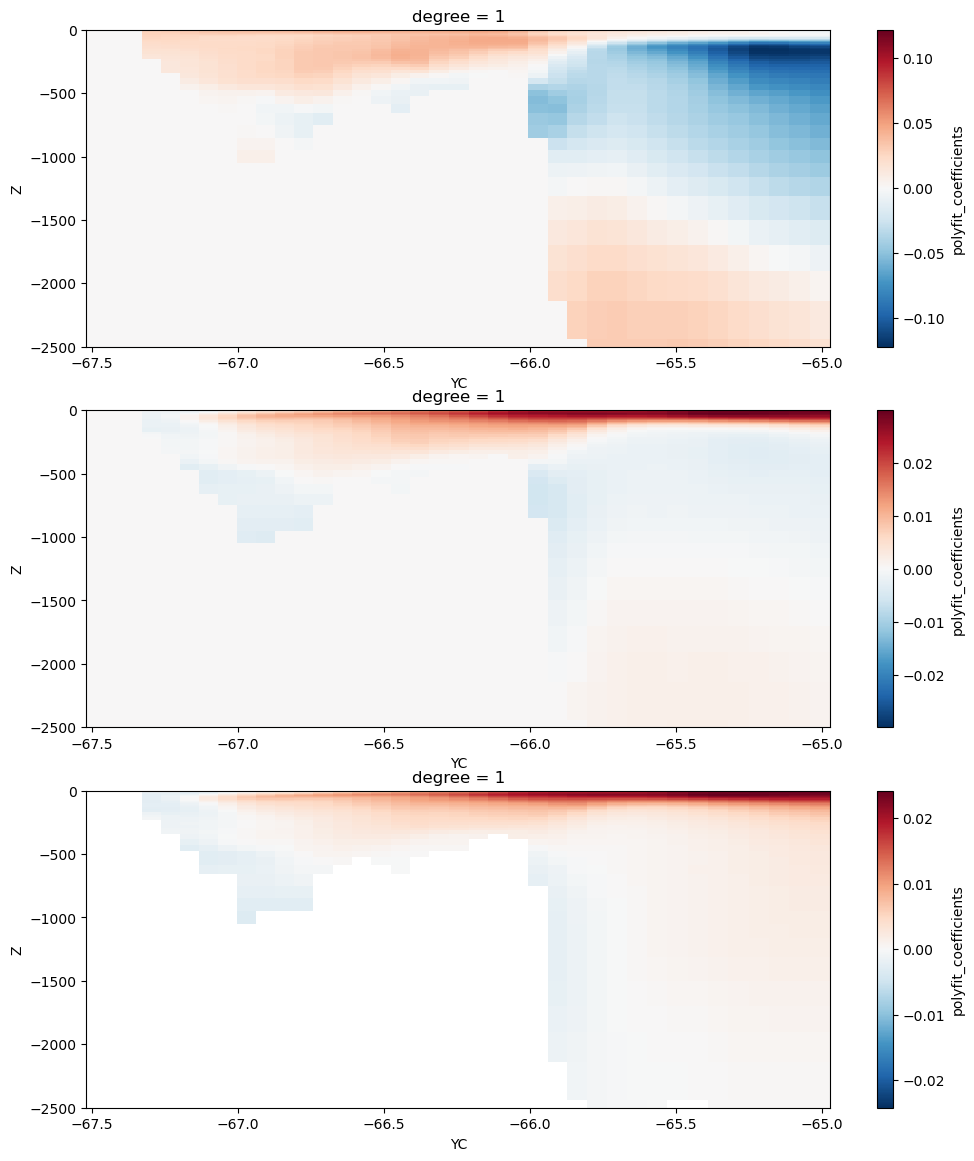

In [19]:
theta_trend = fns.get_trend(ds.THETA)
psal_trend = fns.get_trend(ds.SALT)
sigma_trend = fns.get_trend(ds.sigma0)

fig,axs = plt.subplots(3,1,figsize=(12,14))

ax=axs[0]
theta_trend.plot(x='YC',y='Z',ax=ax)
ax.set_ylim([-2500,0])

ax=axs[1]
psal_trend.plot(x='YC',y='Z',ax=ax)
ax.set_ylim([-2500,0])

ax=axs[2]
sigma_trend.plot(x='YC',y='Z',ax=ax)
ax.set_ylim([-2500,0])

In [20]:
ds['thetav'] = ds.THETA.interp({'YC':ds.YG})
ds['thetavvel'] = ds.thetav * ds.VVEL

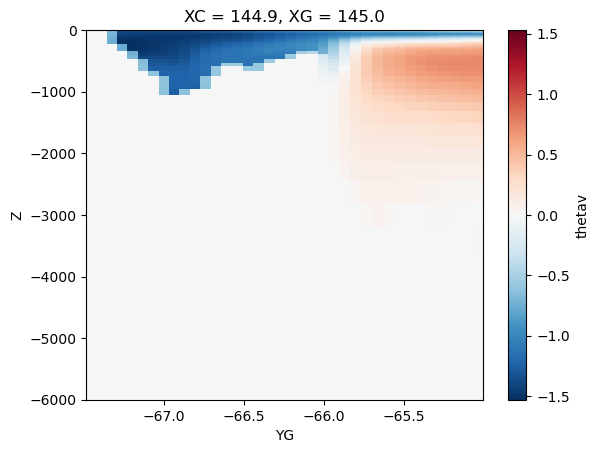

In [38]:
ds.mean('time').thetav.plot()

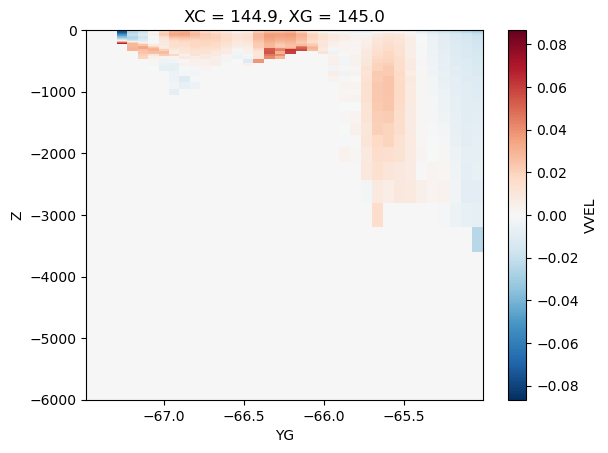

In [33]:
ds.mean('time').VVEL.plot()

(-1000.0, 0.0)

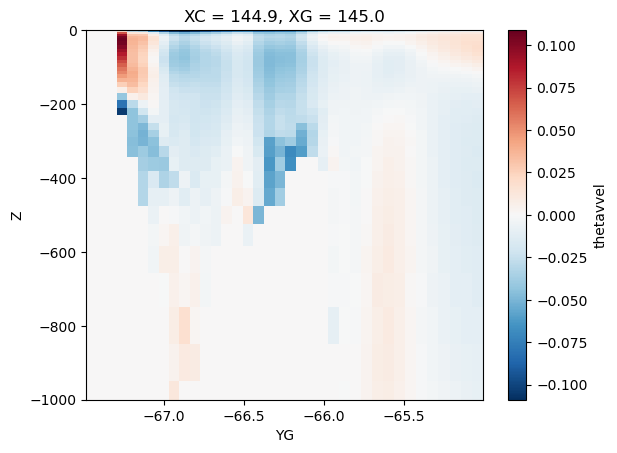

In [40]:
ds.mean('time').thetavvel.plot()
plt.gca().set_ylim([-1000,0])


In [44]:
tmp=ds.mean('time').thetavvel.sel(YG=-66.2,method='nearest')

In [48]:
tmp.Z

<xarray.DataArray 'Z' (Z: 52)> Size: 416B
array([-2.100e+00, -6.700e+00, -1.215e+01, -1.855e+01, -2.625e+01, -3.525e+01,
       -4.500e+01, -5.500e+01, -6.500e+01, -7.500e+01, -8.500e+01, -9.500e+01,
       -1.050e+02, -1.150e+02, -1.250e+02, -1.350e+02, -1.465e+02, -1.615e+02,
       -1.800e+02, -2.000e+02, -2.200e+02, -2.400e+02, -2.600e+02, -2.800e+02,
       -3.010e+02, -3.270e+02, -3.610e+02, -4.025e+02, -4.500e+02, -5.000e+02,
       -5.515e+02, -6.140e+02, -7.000e+02, -8.000e+02, -9.000e+02, -1.000e+03,
       -1.100e+03, -1.225e+03, -1.400e+03, -1.600e+03, -1.800e+03, -2.010e+03,
       -2.270e+03, -2.610e+03, -3.000e+03, -3.400e+03, -3.800e+03, -4.200e+03,
       -4.600e+03, -5.000e+03, -5.400e+03, -5.800e+03])
Coordinates:
    YG       float64 8B -66.21
  * Z        (Z) float64 416B -2.1 -6.7 -12.15 ... -5e+03 -5.4e+03 -5.8e+03
    XC       float64 8B 144.9
    XG       float64 8B 145.0
    dyC      float64 8B 7.475e+03
    dxG      float64 8B 7.475e+03
    rAs      float64 8B 5.587e+07
    drF      (Z) float64 416B 4.2 5.0 5.9 6.9 8.5 ... 400.0 400.0 400.0 400.0
    hFacS    (Z) float64 416B 1.0 1.0 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0 0.0 0.0
Attributes:
    axis:     Z

In [47]:
tmp.integrate('Z')
tmp.where(tmp < 0,drop=True).integrate('Z')

<xarray.DataArray 'thetavvel' ()> Size: 8B
array(14.50938776)
Coordinates:
    YG       float64 8B -66.21
    XC       float64 8B 144.9
    XG       float64 8B 145.0
    dyC      float64 8B 7.475e+03
    dxG      float64 8B 7.475e+03
    rAs      float64 8B 5.587e+07

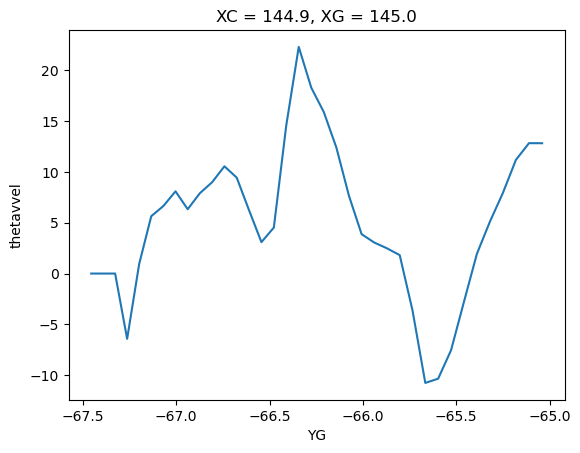

In [36]:
ds.mean('time').thetavvel.integrate('Z').plot()

In [21]:
deg = u'\N{DEGREE SIGN}'

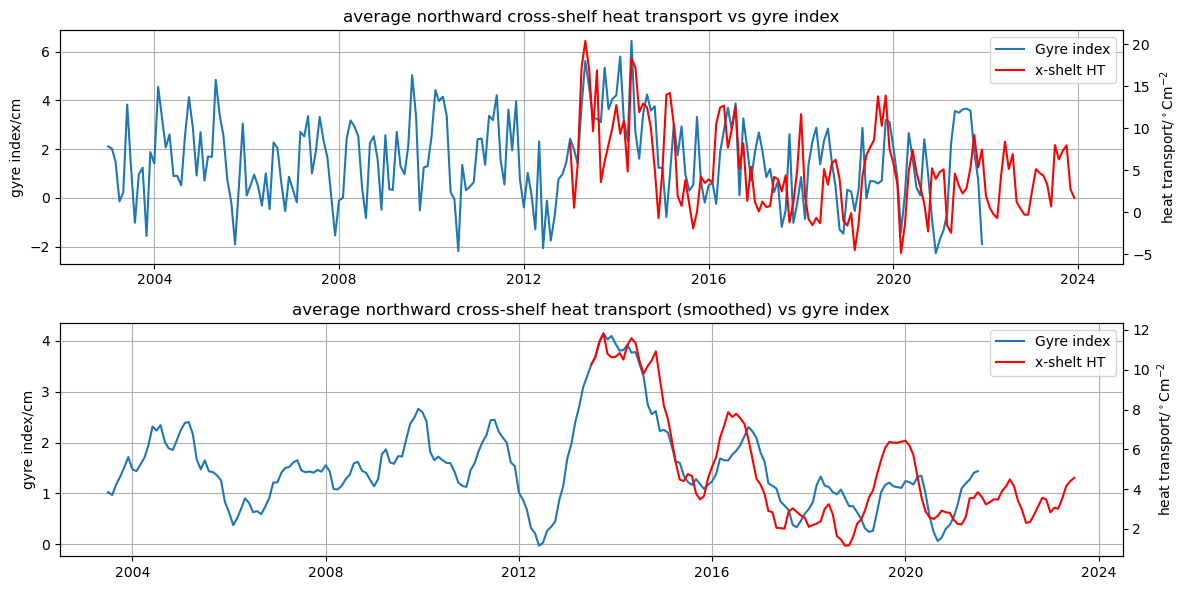

In [25]:
xht = ds.thetavvel.integrate('Z')
fig,axs = plt.subplots(2,1,figsize=(12,6))
ax=axs[0]
ax2=ax.twinx()
l1 = ax.plot(gyre_index.time,gyre_index)
l2 = ax2.plot(ds.time,ds.thetavvel.integrate('Z').mean('YG'),c='r')
ax.legend([l1[0],l2[0]],['Gyre index','x-shelt HT'])
ax.grid()
ax2.set_ylabel(r'heat transport/$^\circ$Cm$^{-2}$')
ax.set_ylabel('gyre index/cm')
ax.set_title('average northward cross-shelf heat transport vs gyre index')

ax=axs[1]
ax2=ax.twinx()
l1=ax.plot(gyre_index.time,gyre_index.rolling({'time':12},center=True).mean())
l2=ax2.plot(ds.time,xht.mean('YG').rolling({'time':12},center=True).mean(),c='r')
ax.legend([l1[0],l2[0]],['Gyre index','x-shelt HT'])
ax.grid()
ax2.set_ylabel(r'heat transport/$^\circ$Cm$^{-2}$')
ax.set_ylabel('gyre index/cm')
ax.set_title('average northward cross-shelf heat transport (smoothed) vs gyre index')

plt.tight_layout()



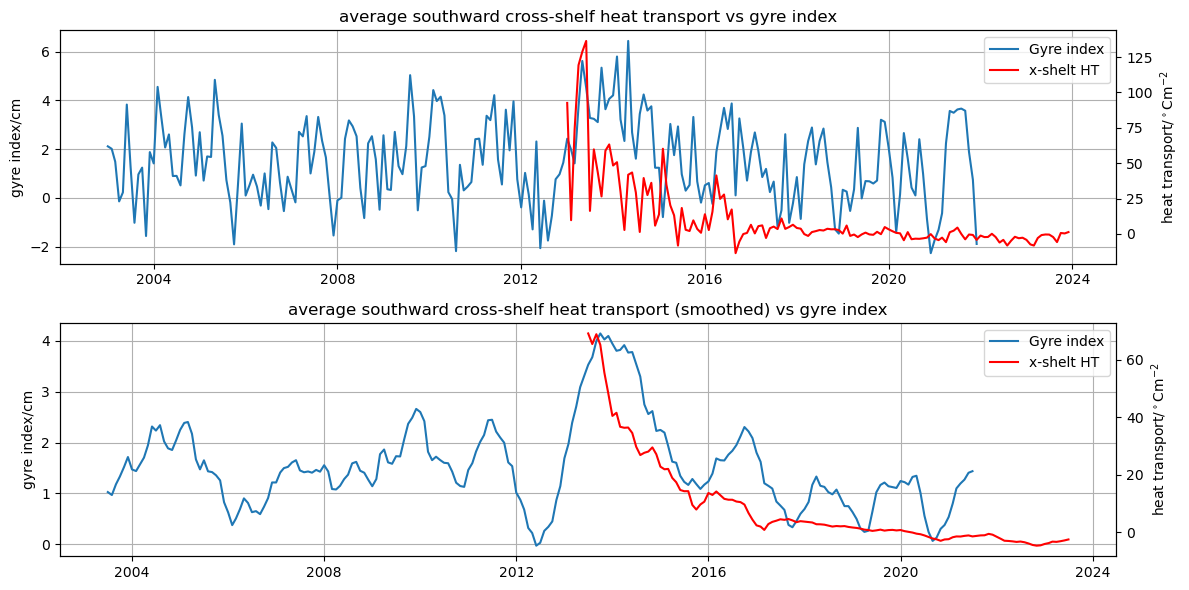

In [23]:
#repeat for l
l = -65.2
dsl = ds.sel(YG=l,method='nearest')
xht = dsl.thetavvel.integrate('Z')

fig,axs = plt.subplots(2,1,figsize=(12,6))
ax=axs[0]
ax2=ax.twinx()
l1 = ax.plot(gyre_index.time,gyre_index)
l2 = ax2.plot(ds.time,xht,c='r')
ax.legend([l1[0],l2[0]],['Gyre index','x-shelt HT'])
ax.grid()
ax2.set_ylabel(r'heat transport/$^\circ$Cm$^{-2}$')
ax.set_ylabel('gyre index/cm')
ax.set_title('average southward cross-shelf heat transport vs gyre index')

ax=axs[1]
ax2=ax.twinx()
l1=ax.plot(gyre_index.time,gyre_index.rolling({'time':12},center=True).mean())
l2=ax2.plot(ds.time,xht.rolling({'time':12},center=True).mean(),c='r')
ax.legend([l1[0],l2[0]],['Gyre index','x-shelt HT'])
ax.grid()
ax2.set_ylabel(r'heat transport/$^\circ$Cm$^{-2}$')
ax.set_ylabel('gyre index/cm')
ax.set_title('average southward cross-shelf heat transport (smoothed) vs gyre index')

plt.tight_layout()



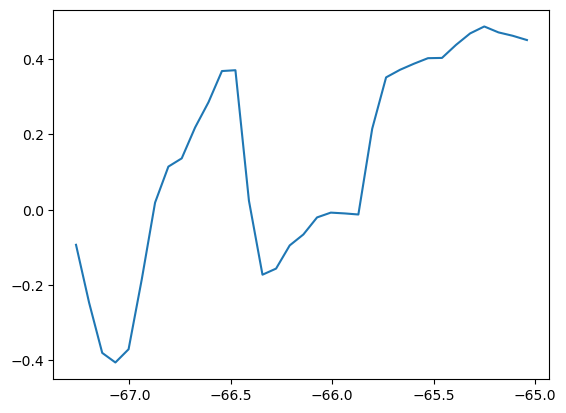

In [33]:
plt.plot(ds.YG,corr)

In [31]:
corr=[]
maxl=0
gic = gyre_index.sel(time=slice(xht.time[0],gyre_index.time[-1]))
dsc = ds.sel(time=slice(xht.time[0],gyre_index.time[-1]))
for yg in dsc.YG:
    dsyg = dsc.sel(YG=yg)
    xhtyg = dsyg.thetavvel.integrate('Z')
    cc = xr.corr(gic,xhtyg)
    corr.append(cc.item())
    

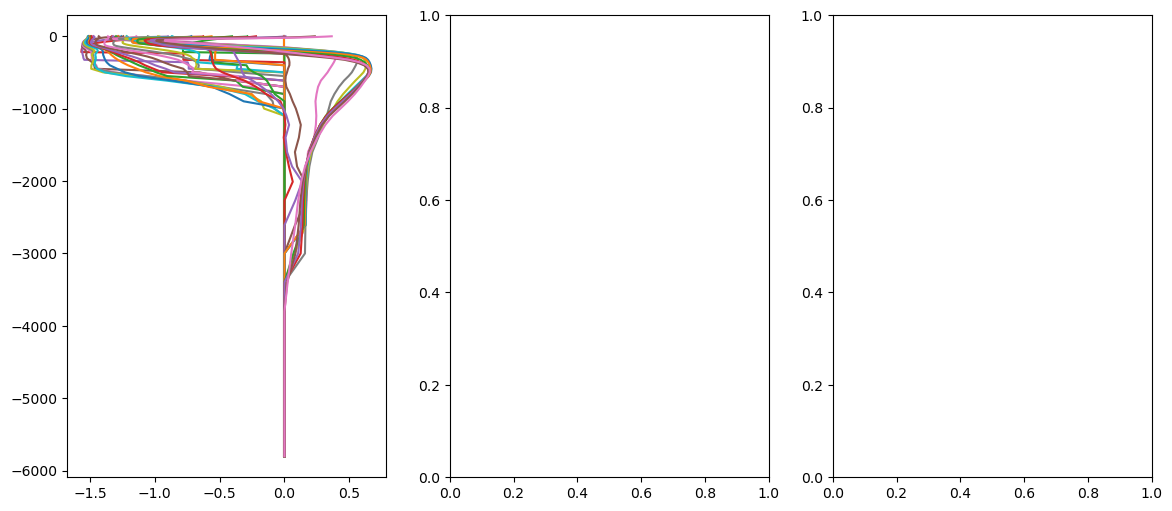

In [31]:
j20 = ds.sel(time=pd.Timestamp(2020,1,1),method='nearest')

fig,axs = plt.subplots(1,3,figsize=(14,6))
axs[0].plot(j20.thetav,j20.Z)

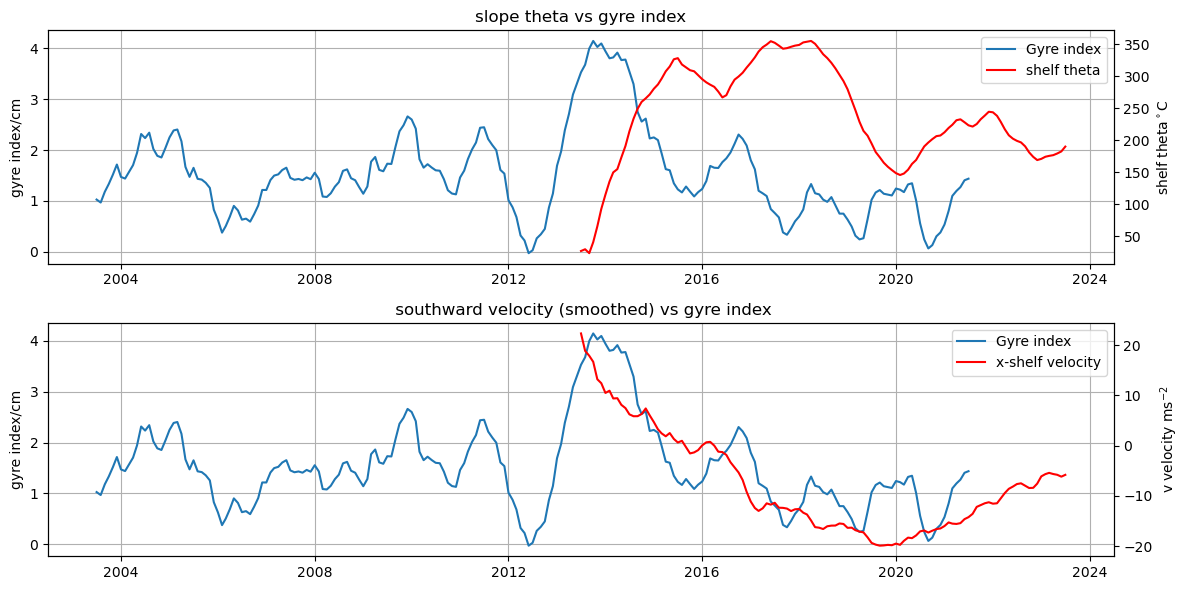

In [18]:
fig,axs = plt.subplots(2,1,figsize=(12,6))
ax=axs[0]
l1 = ax.plot(gyre_index.time,gyre_index.rolling({'time':12},center=True).mean())
ax2=ax.twinx()
l2 = ax2.plot(ds.time,ds.thetav.integrate('Z').mean('YG').rolling({'time':12},center=True).mean(),c='r')
ax.legend([l1[0],l2[0]],['Gyre index','shelf theta'])
ax.grid()
ax2.set_ylabel(r'shelf theta$^\circ$C')
ax.set_ylabel('gyre index/cm')
ax.set_title('slope theta vs gyre index')

ax=axs[1]
ax2=ax.twinx()
l1=ax.plot(gyre_index.time,gyre_index.rolling({'time':12},center=True).mean())
l2=ax2.plot(ds.time,ds.VVEL.integrate('Z').mean('YG').rolling({'time':12},center=True).mean(),c='r')
ax.legend([l1[0],l2[0]],['Gyre index','x-shelf velocity'])
ax.grid()
ax2.set_ylabel(r'v velocity ms$^{-2}$')
ax.set_ylabel('gyre index/cm')
ax.set_title(' southward velocity (smoothed) vs gyre index')

plt.tight_layout()

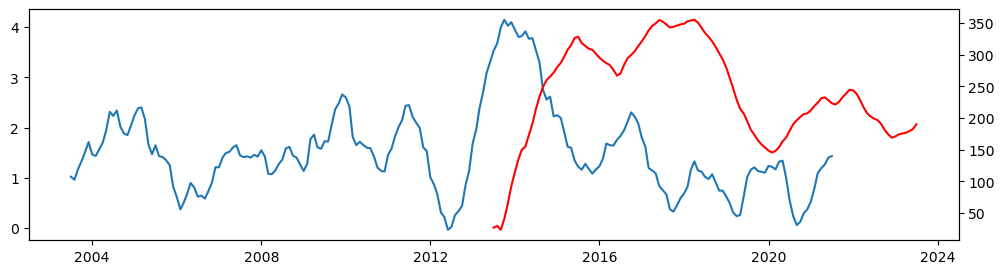

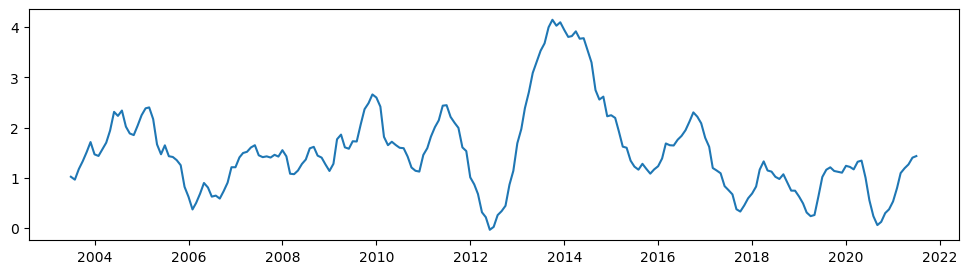

In [19]:

fig,ax = plt.subplots(figsize=(12,3))
ax.plot(gyre_index.time,gyre_index.rolling({'time':12},center=True).mean())
ax.twinx().plot(ds.time,ds.thetav.integrate('Z').mean('YG').rolling({'time':12},center=True).mean(),c='r')

fig,ax = plt.subplots(figsize=(12,3))
ax.plot(gyre_index.time,gyre_index.rolling({'time':12},center=True).mean())


In [20]:
s_sigma = fns.season_split(ds.sigma0)
s_theta = fns.season_split(ds.THETA)
s_salty = fns.season_split(ds.SALT)


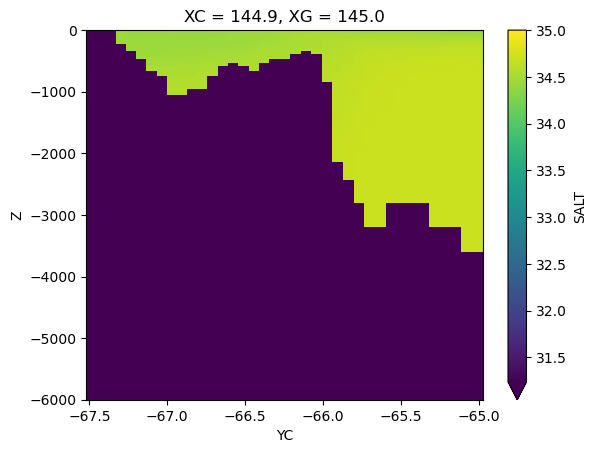

In [21]:
s_salty['spring'].mean('time').plot(vmin=35)

In [22]:
dss = fns.season_split(ds.sigma0)

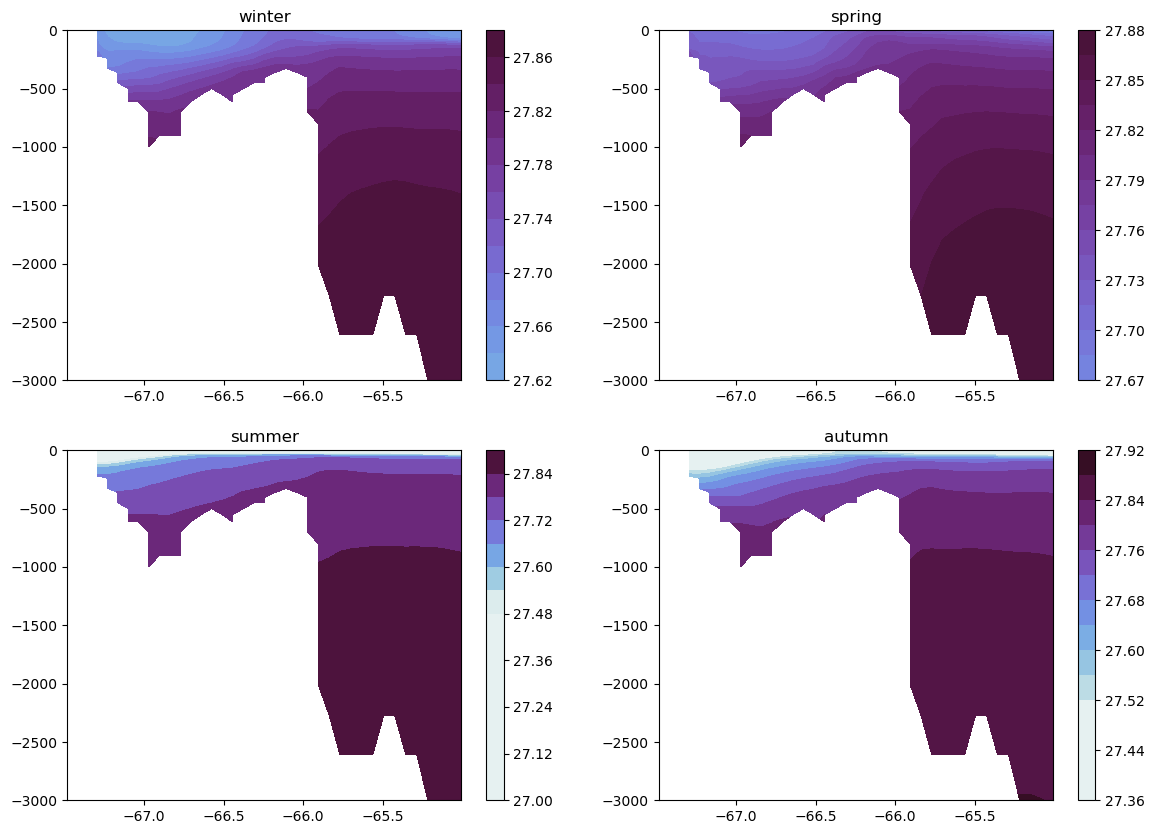

In [23]:
fig,axs = plt.subplots(2,2,figsize=(14,10))

def plotit(ax,s):
    im=ax.contourf(ds.YC,ds.Z,dss[s].mean('time'),vmax=27.9,vmin=27.5,levels=15,cmap=cmocean.cm.dense)
    ax.set_ylim([-3000,0])
    ax.set_title(s)
    plt.colorbar(im)

plotit(axs[0][0],'winter')
plotit(axs[0][1],'spring')
plotit(axs[1][0],'summer')
plotit(axs[1][1],'autumn')



In [ ]:
fig,axs = plt.subplots(2,2,figsize=(14,10))
dss = fns.season_split(ds.THETA)
def plotit(ax,s):
    im=ax.contourf(ds.YC,ds.Z,dss[s].mean('time'),vmax=1,vmin=-1.5,levels=15,cmap=cmocean.cm.dense)
    ax.set_ylim([-3000,0])
    ax.set_title(s)
    plt.colorbar(im)

plotit(axs[0][0],'winter')
plotit(axs[0][1],'spring')
plotit(axs[1][0],'summer')
plotit(axs[1][1],'autumn')

In [ ]:
#LABEL water masstypes
ds['wmt'] = ds.sigma0 * np.nan

In [ ]:
ds['wmt'].where((ds.sigma0 > 27.7) & ,'mCDW')